<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/exercises/ImageProcessingEx_04_EdgeDetection_HoughTransformipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl">

# מטלה 4 - זיהוי קצוות ואלגוריתם HoughTransform

 יש לכתוב בתחילת המחברת את שמות הסטודנטים ומספרי תעודת הזהות בפורמט הבא:

שם פרטי+שם משפחה + ת"ז:

Xxxxx XXXXX, #nnnnnn

<div>



<div dir="rtl">

**הנחיות כלליות**:

* המטלה בזוגות, במקרה של בקשות אישיות ניתן לשלוח מייל

* כתבו את הקוד שלכם באזורי ה־TODO (האזורים שסומנו לכך מראש).
ניתן להוסיף פונקציות עזר משלכם אם תרצו.

* העלו את הפתרון ללמדה ע"י  הקישור למחברת ה־Colab שלכם
(ממוקמת ב־Google Drive) עם הרשאת “Commenter” לכתובת ariela7870451@gmail.com

* המחברת צריכה להיראות תקינה ולהיות ניתנת להרצה מלאה ע"י הפקודה
“Run all”  ללא שגיאות.
במקרה של שגיאות, ההגשה תיפסל.


* הציון יינתן לפי:
רמת הביצוע הנכונה של האלגוריתם על מספר תמונות בגווני אפור
וניקיון הקוד (תיעוד, הערות, מבנה קריא).

* אל תשכחו להוסיף את שמותיכם ומספרי תעודת הזהות בראש המחברת.

* כל התמונות הן מטריצות דו־ממדיות מסוג float עם ערכים בטווח [0..1].
* כל הפונקציות  חייבות להחזיר תמונות באותו גודל של התמונות המקוריות!

<div>


<div dir="rtl">

### הפונקציות למימוש:

1. ממשו את הפונקציה `edge_detect` אשר מוצאת את פיקסלי הקצה ע"י Canny Edge Detector.
*  יש לזכור לבצע החלקה (smoothing) לתמונה לפני שלב גילוי השפות.

 קלט הפונקציה:

* תמונה בגווני אפור.

 פלט הפונקציה:
* תמונה בינארית המכילה רק את השפות
(מטריצה עם ערכים 0 ו־1 בלבד, כאשר 1 מייצג שפה).
* `tg_theta` מטריצה המכילה את הטנגנס של זווית הגרדיאנט בכל פיקסל.

יש להשתמש ב־hysteresis thresholding עם שני ספים:
* `t_high`
* `t_low`
2. ממשו את הפונקציה `find_circles` שמטרתה לזהות מעגלים בתמונה בגווני אפור באמצעות התמרת Hough.

הפונקציה צריכה:
* להדפיס רשימה של כל המעגלים שנמצאו בתמונה.
 ולהחזיר מטריצה שבה כל שורה מייצגת מעגל אחד וכוללת 3 ערכים: `origin_x`, `origin_y`, `radius`.
* בנוסף יש להחזיר תמונה `img_c` אשר מכילה את התמונה המקורית ועליה מסומנים המעגלים שנמצאו (יש לצייר את המעגלים על התמונה).
* הפונקציה `find_circles` חייבת להשתמש קודם בפונקציה `edge_detect` על התמונה הנתונה ורק לאחר מכן לבצע התמרת Hough.

**זכרו להשתמש ב`tg_theta` על מנת לשפר את הסיבוכיות ריצה.**


**שימו לב:**
* בתמונות המטלה הזאת **1** מייצג אובייקט ו**0** מצייג רקע.
* עליכם לוודא שהפונקציה פועלת על `balls4.tiff`.

**בהצלחה.**

In [1]:
import os
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL
from scipy.signal import convolve

In [2]:
GITHUB_PATH = 'https://raw.githubusercontent.com/ArielaLevkov/ImageProcessing_TA/main/images/'

In [3]:
def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, file_name)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [4]:
def plot_images(img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
    axes[0].imshow(img1,  cmap='gray')
    axes[1].imshow(img2,  cmap='gray')

## `edge_detect`

In [5]:
def edge_detect(img: np.array, t_low: np.float32, t_high: np.float32) \
    -> (np.array, np.array):
    '''
    This function receives a grayscale image and locate its edges using the
    Canny Edge Detector algorithm.

    Args:
        img:    image array in float format (range: 0..1) - the source grayscale
                image.
        t_low:  float format (range: 0..1), the Low threshold value.
        t_high: float format (range: 0..1), the High threshold value.

    Returns:
        img_e:    array in int format (values: 0, 1) - binary image with edges
                    pixels set to 1.
        tg_theta: array in float format (range: 0..1) - the matrix of the
                    tangents of the gradients angles.
    '''
    ######################################################################
    # TODO: Implement The edge_detect algorithm.
    ######################################################################
    pass
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_e, tg_theta

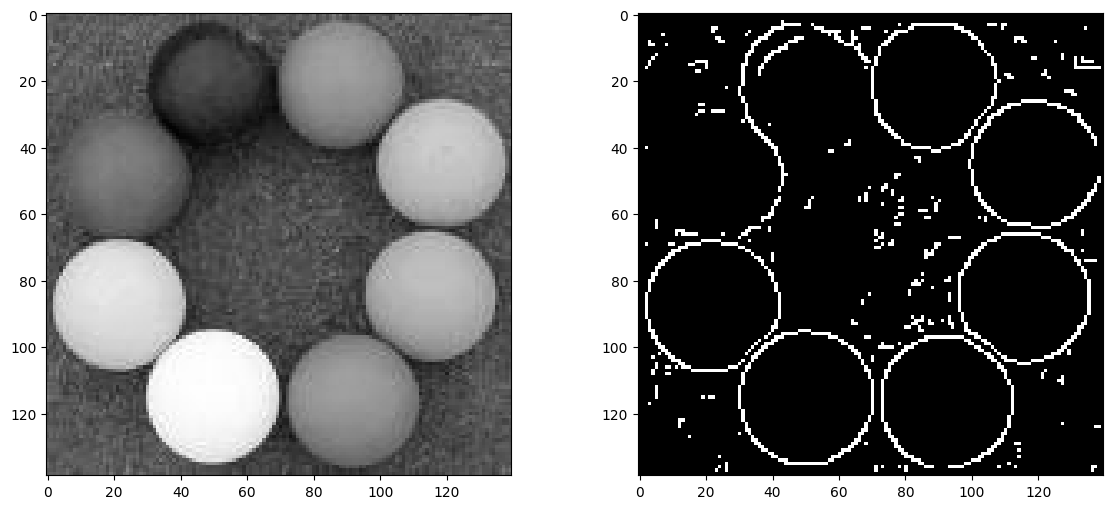

In [6]:
img1 = read_file(file_name='balls1.tiff') / 255
img1_e, tg_theta1 = edge_detect(img=img1, t_low=9/255, t_high=10/255)
plot_images(img1, img1_e)

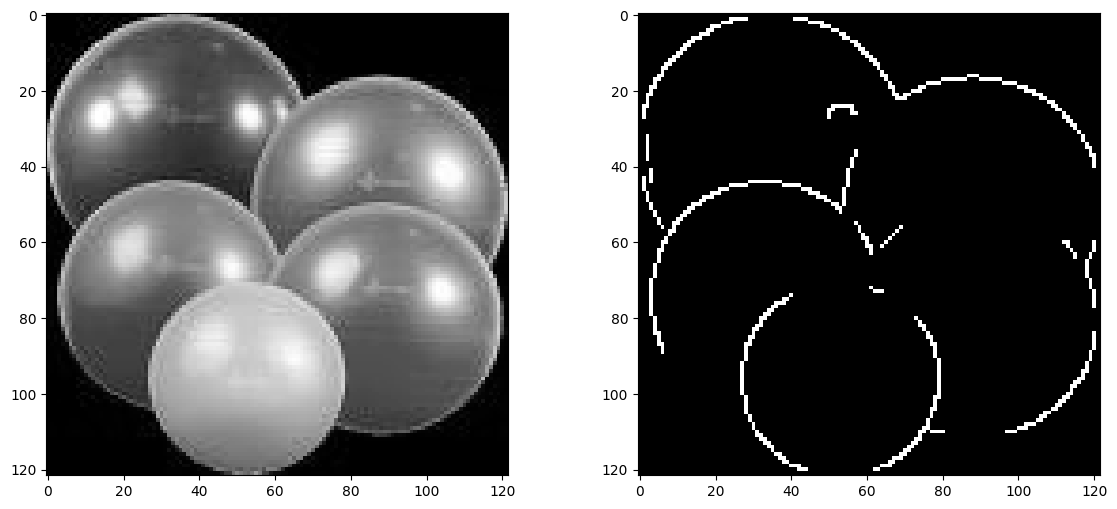

In [7]:
img4 = read_file(file_name='balls4.tiff') / 255
img4_e, tg_theta = edge_detect(img=img4, t_low=33/255, t_high=40/255)
plot_images(img4, img4_e)

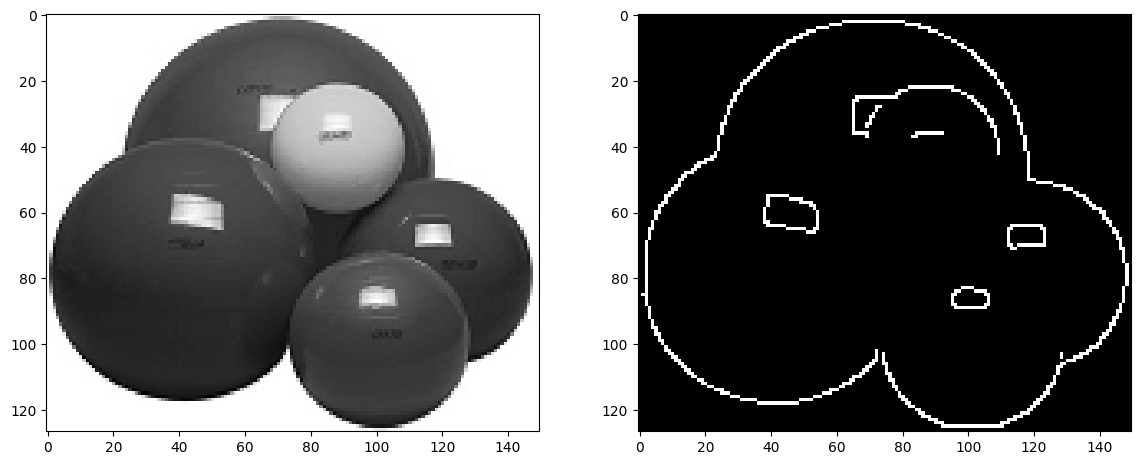

In [8]:
img5 = read_file(file_name='balls5.tiff') / 255
img5_e, tg_theta5 = edge_detect(img=img5, t_low=20/255, t_high=40/255)
plot_images(img5, img5_e)

## `find_circles`

In [9]:
def find_circles(img: np.array, t_low: np.float32, t_high: np.float32) -> (np.array, list):
    '''
    This function receives a grayscale image and finds circles in it using Hough
    transform.
    The function is using the edge_detect function on the given image before
    performing the Hough transform.
    It also use the tg_theta array to improve the complexity of the algorithm.
    The function also returns a list of the found circles.

    Args:
        img:    image array in float format (range: 0..1) - the source grayscale
                image.
        t_low:  float format (range: 0..1), the Low threshold value.
        t_high: float format (range: 0..1), the High threshold value.

    Returns:
        img_c:   RGB image array in float format (range: 0..1) which contains
                    the original image and the marked circles which were found.
        circles: a list - each element represent a circle and contains a list of
                    3 values: origin_x, origin_y, radius
    '''
    ######################################################################
    # TODO: Implement The find_circles algorithm.
    ######################################################################
    pass
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_c, circles

[[42, 78, 40], [70, 48, 47], [89, 42, 20], [102, 100, 26], [120, 79, 28]]


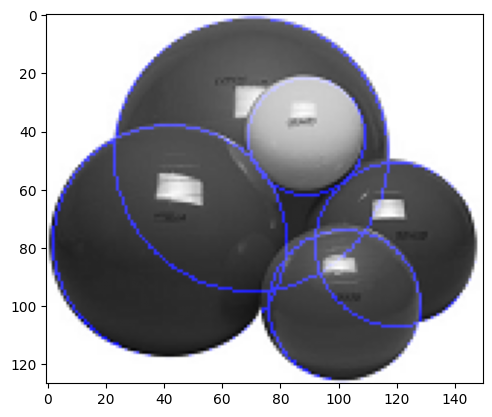

In [10]:
img = read_file(file_name='balls5.tiff') / 255
img_c, circles = find_circles(img=img, t_low=20/255, t_high=40/255)

img_rgb = np.dstack((img, img, img))
img_rgb[:,:,2] += img_c
img_rgb = img_rgb.clip(0,1)
plt.imshow(img_rgb);
print(circles)

[[33, 74, 30], [36, 37, 37], [53, 96, 26], [89, 49, 33], [90, 80, 31]]


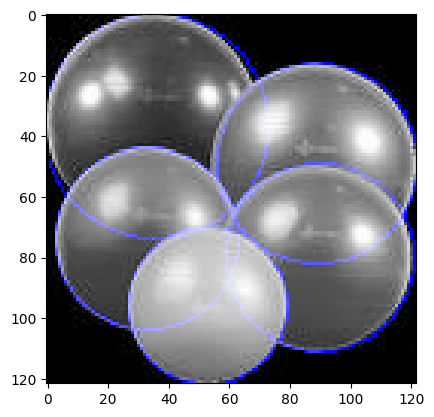

In [11]:
img = read_file(file_name='balls4.tiff') / 255
img_c, circles = find_circles(img=img, t_low=33/255, t_high=40/255)

img_rgb = np.dstack((img, img, img))
img_rgb[:,:,2] += img_c
img_rgb = img_rgb.clip(0,1)
plt.imshow(img_rgb);
print(circles)